# Mini-CLIP: Contrastive Image-Text Learning

This notebook introduces a contrastive learning approach for image-text matching.

Unlike [the previous binary classifiers](https://github.com/Maxstef/flickr30k-multimodal-retrieval/blob/main/notebooks/04_neural_multimodal_classifier.ipynb), Mini-CLIP does not directly predict whether an image-caption pair is a match. Instead, it learns a shared embedding space where matching images and captions are close together, while non-matching pairs are pushed apart.

This approach is motivated by [the error analysis](https://github.com/Maxstef/flickr30k-multimodal-retrieval/blob/main/notebooks/05_error_analysis.ipynb), where many remaining mistakes involved semantically similar but incorrect captions.

## Goal

The goal of this notebook is to build a lightweight CLIP-style model that learns aligned image and text representations.

The model will:

1. Encode images into fixed-size embeddings.
2. Encode captions into embeddings of the same size.
3. Compare image and text embeddings using similarity scores.
4. Train using contrastive loss so that correct image-caption pairs are closer than incorrect pairs.

## From Binary Classification to Contrastive Learning

[Previous models](https://github.com/Maxstef/flickr30k-multimodal-retrieval/blob/main/notebooks/04_neural_multimodal_classifier.ipynb) treated image-text matching as a binary classification task. Each image-caption pair was labeled as either matching or non-matching, and the model learned to output a probability.

Mini-CLIP uses a different strategy. It learns separate image and text encoders and trains them so that matching image-caption embeddings are similar. Negative examples are created implicitly within each batch: every other caption in the batch acts as a negative example for a given image.

This removes the need to manually generate negative pairs and encourages the model to learn a more general image-text representation.

## Setup and Imports

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [2]:
import pandas as pd
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from src.config import (
    DATASET_NAME,
    RANDOM_SEED,
    DEVICE,
    BATCH_SIZE,
    MAX_CAPTION_LENGTH,
    EMBEDDING_DIM,
)

from src.data.loaders import load_flickr30k_splits
from src.text.tokenization import build_vocab
from src.features.image_features import get_resnet18_transforms

In [3]:
print(f"Using device: {DEVICE}")

Using device: mps


## Load Dataset

Unlike the previous experiments, Mini-CLIP is trained **only on the original image-caption pairs** from the Flickr30k dataset. Negative examples are not generated explicitly. Instead, during training, every other caption within a mini-batch serves as a negative example for a given image, and vice versa.

This simplifies the data preparation pipeline while enabling contrastive learning over many image-text relationships simultaneously.

In [4]:
train_data, val_data, test_data = load_flickr30k_splits(DATASET_NAME)

print(f"Train samples: {len(train_data):,}")
print(f"Validation samples: {len(val_data):,}")
print(f"Test samples: {len(test_data):,}")

Train samples: 29,000
Validation samples: 1,014
Test samples: 1,000


### Build Vocabulary

Captions are tokenized and converted into integer token IDs using the same vocabulary construction procedure developed in the previous notebooks. Reusing the same preprocessing pipeline allows the focus to remain on the new contrastive learning objective rather than on changes to text representation.

In [6]:
vocab = build_vocab(
    train_data["caption"],
    min_freq=1,
)

print(f"Vocabulary size: {len(vocab):,}")

Vocabulary size: 17,714


## Contrastive Dataset Design

Mini-CLIP is trained using precomputed ResNet18 image embeddings instead of raw images. Since the image encoder is frozen, image features can be extracted once and reused during training, which avoids repeatedly passing images through ResNet18 and keeps the contrastive learning experiment computationally efficient.

Since each Flickr30k image is associated with five valid captions, one caption is randomly selected for each image at the beginning of every training epoch. This reduces the likelihood of treating another valid caption for the same image as a negative example within a mini-batch while keeping the implementation simple.

Each dataset item returns:

- a precomputed image embedding,
- an encoded caption tensor.


### Image Feature Extraction

image embeddings are extracted once before training

In [10]:
from src.features.image_features import (
    get_resnet18_feature_extractor,
    get_resnet18_transforms,
    extract_image_features,
)

image_feature_extractor = get_resnet18_feature_extractor(DEVICE)
image_transform = get_resnet18_transforms()

train_image_features = extract_image_features(
    train_data,
    image_feature_extractor,
    image_transform,
    DEVICE,
)

val_image_features = extract_image_features(
    val_data,
    image_feature_extractor,
    image_transform,
    DEVICE,
)

100%|██████████| 1014/1014 [00:11<00:00, 84.54it/s]


In [56]:
from src.datasets.contrastive_dataset import Flickr30kContrastiveEmbeddingDataset

train_dataset = Flickr30kContrastiveEmbeddingDataset(
    hf_dataset=train_data,
    image_features=train_image_features,
    vocab=vocab,
    max_length=MAX_CAPTION_LENGTH,
    caption_strategy="random",
)

val_dataset = Flickr30kContrastiveEmbeddingDataset(
    hf_dataset=val_data,
    image_features=val_image_features,
    vocab=vocab,
    max_length=MAX_CAPTION_LENGTH,
    caption_strategy="first",
)

len(train_dataset), len(val_dataset)

(29000, 1014)

In [57]:
image, caption = train_dataset[0]

image.shape, caption.shape

(torch.Size([512]), torch.Size([32]))

## DataLoaders

In [58]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

In [32]:
image_embeddings, captions = next(iter(train_loader))

print("Image embeddings:", image_embeddings.shape)
print("Captions:", captions.shape)

Image embeddings: torch.Size([32, 512])
Captions: torch.Size([32, 32])


## Mini-CLIP Model Architecture

Mini-CLIP uses two separate encoders: one for images and one for text. Instead of concatenating image and text features and passing them through a binary classifier, the model projects both modalities into the same embedding space.

For this implementation, images are represented by precomputed 512-dimensional ResNet18 embeddings. These image features are projected into a lower-dimensional shared embedding space. Captions are encoded using a trainable word embedding layer followed by mean pooling, and then projected into the same shared space.

After projection, both image and text embeddings are normalized. This allows their dot product to represent cosine similarity. During training, each image is compared with every caption in the batch, producing a similarity matrix where the diagonal contains the correct image-caption pairs.

The model itself does not output match probabilities. Instead, it outputs image and text embeddings, and the contrastive loss is responsible for learning which pairs should be close together and which should be far apart.

In [ ]:
from src.models.mini_clip import MiniCLIP
from src.config import PROJECTION_DIM, IMAGE_FEATURE_DIM

model = MiniCLIP(
    vocab_size=len(vocab),
    text_embedding_dim=EMBEDDING_DIM,
    image_feature_dim=IMAGE_FEATURE_DIM,
    projection_dim=PROJECTION_DIM,
).to(DEVICE)

model

MiniCLIP(
  (image_projection): Linear(in_features=512, out_features=256, bias=True)
  (text_embedding): Embedding(17714, 128, padding_idx=0)
  (text_projection): Linear(in_features=128, out_features=256, bias=True)
)

In [34]:
# Test one forward pass
image_embeddings, captions = next(iter(train_loader))

image_embeddings = image_embeddings.to(DEVICE)
captions = captions.to(DEVICE)

image_proj, text_proj = model(image_embeddings, captions)

image_proj.shape, text_proj.shape

(torch.Size([32, 256]), torch.Size([32, 256]))

## Contrastive Loss

Mini-CLIP compares every image embedding with every text embedding in the same mini-batch. This produces a similarity matrix where each row represents one image and each column represents one caption.

The diagonal values correspond to the correct image-caption pairs. All off-diagonal values are treated as negative pairs.

The loss is computed in both directions:

- image → text: each image should select its matching caption;
- text → image: each caption should select its matching image.

The final loss is the average of these two losses.

In [35]:
from src.training.contrastive_loss import CLIPContrastiveLoss

loss_fn = CLIPContrastiveLoss(
    temperature=0.07,
)

In [36]:
# sanity check
image_embeddings, captions = next(iter(train_loader))

image_embeddings = image_embeddings.to(DEVICE)
captions = captions.to(DEVICE)

image_proj, text_proj = model(image_embeddings, captions)

loss = loss_fn(image_proj, text_proj)

loss

tensor(3.7520, device='mps:0', grad_fn=<DivBackward0>)

## Training Mini-CLIP

The Mini-CLIP model is trained using contrastive loss. For each batch, the model produces image and text embeddings, computes the similarity matrix between them, and updates the projection layers and text encoder so that matching image-caption pairs become closer in the shared embedding space.

In [37]:
from src.training.clip_engine import train_clip_one_epoch, evaluate_clip
from src.config import LEARNING_RATE, CLIP_NUM_EPOCHS

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
)

In [38]:
from timeit import default_timer as timer

clip_history = []

train_start = timer()

for epoch in range(CLIP_NUM_EPOCHS):
    print(f"\nEpoch {epoch + 1}/{CLIP_NUM_EPOCHS}")

    train_loss = train_clip_one_epoch(
        model=model,
        dataloader=train_loader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        device=DEVICE,
    )

    val_loss = evaluate_clip(
        model=model,
        dataloader=val_loader,
        loss_fn=loss_fn,
        device=DEVICE,
    )

    epoch_results = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
    }

    clip_history.append(epoch_results)

    print(
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f}"
    )

train_end = timer()

print(f"\nTraining time: {train_end - train_start:.1f} seconds")


Epoch 1/10


Evaluating: 100%|██████████| 32/32 [00:01<00:00, 16.89it/s]


Train loss: 2.5139 | Val loss: 2.2029

Epoch 2/10


Evaluating: 100%|██████████| 32/32 [00:01<00:00, 16.86it/s]


Train loss: 1.9565 | Val loss: 2.0049

Epoch 3/10


...

Train loss: 1.2074 | Val loss: 1.5164

Epoch 9/10


Evaluating: 100%|██████████| 32/32 [00:01<00:00, 18.00it/s]


Train loss: 1.1573 | Val loss: 1.4856

Epoch 10/10


Evaluating: 100%|██████████| 32/32 [00:01<00:00, 18.21it/s]

Train loss: 1.1107 | Val loss: 1.4286

Training time: 592.4 seconds


In [39]:
clip_history_df = pd.DataFrame(clip_history)
clip_history_df

,epoch,train_loss,val_loss
0,1,2.513938,2.202928
1,2,1.956512,2.004930
2,3,1.708232,1.852796
3,4,1.559983,1.736716
4,5,1.435143,1.646400
5,6,1.347482,1.625177
6,7,1.274392,1.548789
7,8,1.207395,1.516415
8,9,1.157306,1.485601
9,10,1.110737,1.428562


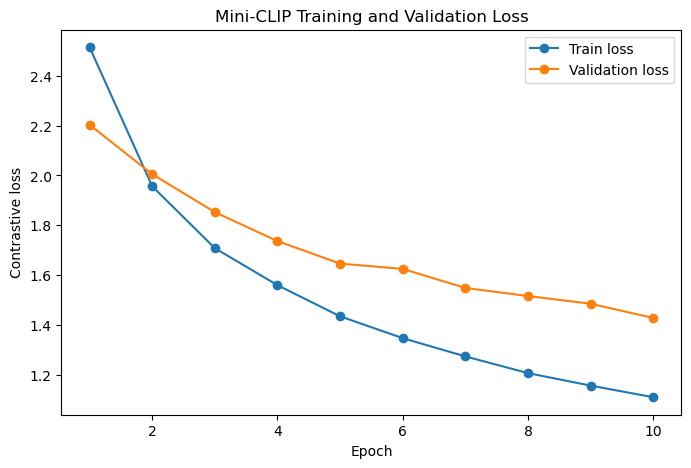

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(clip_history_df["epoch"], clip_history_df["train_loss"], marker="o", label="Train loss")
plt.plot(clip_history_df["epoch"], clip_history_df["val_loss"], marker="o", label="Validation loss")

plt.title("Mini-CLIP Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Contrastive loss")
plt.legend()

plt.show()

It looks like we can try few more epochs

In [41]:
from src.config import MODELS_DIR
from timeit import default_timer as timer
import torch

ADDITIONAL_EPOCHS = 6

best_val_loss = min(row["val_loss"] for row in clip_history)
best_epoch = min(
    clip_history,
    key=lambda row: row["val_loss"],
)["epoch"]

start_epoch = len(clip_history)

train_start = timer()

for epoch in range(start_epoch, start_epoch + ADDITIONAL_EPOCHS):
    print(f"\nEpoch {epoch + 1}/{start_epoch + ADDITIONAL_EPOCHS}")

    train_loss = train_clip_one_epoch(
        model=model,
        dataloader=train_loader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        device=DEVICE,
    )

    val_loss = evaluate_clip(
        model=model,
        dataloader=val_loader,
        loss_fn=loss_fn,
        device=DEVICE,
    )

    epoch_results = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
    }

    clip_history.append(epoch_results)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            MODELS_DIR / "mini_clip.pt",
        )

    print(
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_loss:.4f}"
    )

train_end = timer()

print(f"\nBest epoch: {best_epoch}")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Additional training time: {train_end - train_start:.1f} seconds")


Epoch 11/16


Evaluating: 100%|██████████| 32/32 [00:02<00:00, 15.53it/s]


Train loss: 1.0663 | Val loss: 1.4843

Epoch 12/16


Evaluating: 100%|██████████| 32/32 [00:01<00:00, 17.90it/s]


Train loss: 1.0364 | Val loss: 1.4131

Epoch 13/16


...

Train loss: 0.9710 | Val loss: 1.3910

Epoch 15/16


Evaluating: 100%|██████████| 32/32 [00:01<00:00, 17.67it/s]


Train loss: 0.9502 | Val loss: 1.4433

Epoch 16/16


Evaluating: 100%|██████████| 32/32 [00:01<00:00, 18.30it/s]


Train loss: 0.9176 | Val loss: 1.3651

Best epoch: 16
Best validation loss: 1.3651
Additional training time: 344.1 seconds


In [44]:
clip_history_df = pd.DataFrame(clip_history)
clip_history_df

,epoch,train_loss,val_loss
0,1,2.513938,2.202928
1,2,1.956512,2.004930
2,3,1.708232,1.852796
3,4,1.559983,1.736716
4,5,1.435143,1.646400
5,6,1.347482,1.625177
6,7,1.274392,1.548789
7,8,1.207395,1.516415
8,9,1.157306,1.485601
9,10,1.110737,1.428562


In [45]:
from src.config import RESULTS_DIR

clip_history_df.to_csv(
    RESULTS_DIR / "mini_clip_training_history.csv",
    index=False,
)

### Observation

The Mini-CLIP model trains successfully, with both training and validation loss decreasing substantially across epochs. Although the validation loss shows some fluctuation, the overall trend indicates that the model is learning a shared image-text embedding space.

Since the contrastive loss continues to improve through the later epochs, the model appears to benefit from additional training. The best checkpoint is saved for the next stage, where the learned embeddings will be evaluated using image-to-text and text-to-image retrieval.

## Embedding Retrieval Evaluation

Mini-CLIP is not evaluated as a binary classifier. Instead, it is evaluated as a retrieval model.

Given an image, the model should retrieve the most relevant caption from a set of candidate captions. Similarly, given a caption, the model should retrieve the matching image.

This section evaluates the learned shared embedding space using Top-K retrieval accuracy. For validation, the first caption for each image is used deterministically, so image `i` is expected to match caption `i`.

In [59]:
from src.evaluation.retrieval import compute_retrieval_metrics

In [60]:
# Create embeddings for the validation set
model.eval()

all_image_embeddings = []
all_text_embeddings = []

with torch.inference_mode():
    for image_embeddings, captions in val_loader:
        image_embeddings = image_embeddings.to(DEVICE)
        captions = captions.to(DEVICE)

        image_proj, text_proj = model(image_embeddings, captions)

        all_image_embeddings.append(image_proj.cpu())
        all_text_embeddings.append(text_proj.cpu())

all_image_embeddings = torch.cat(all_image_embeddings)
all_text_embeddings = torch.cat(all_text_embeddings)

all_image_embeddings.shape, all_text_embeddings.shape

(torch.Size([1014, 256]), torch.Size([1014, 256]))

In [61]:
# Then compute similarity matrix
similarity_matrix = all_image_embeddings @ all_text_embeddings.T

similarity_matrix.shape

torch.Size([1014, 1014])

In [62]:
retrieval_metrics = compute_retrieval_metrics(similarity_matrix)

retrieval_metrics

,direction,top_1,top_5,top_10
0,Image-to-text,0.155819,0.375740,0.503945
1,Text-to-image,0.151874,0.373767,0.504931


In [63]:
retrieval_metrics.to_csv(
    RESULTS_DIR / "mini_clip_retrieval_metrics.csv",
    index=False,
)

### Observation

The retrieval results show that the Mini-CLIP model has learned a meaningful shared embedding space for images and captions. Although the Top-1 retrieval accuracy is relatively modest, the correct match is retrieved within the Top-10 results for approximately half of the validation samples in both retrieval directions. This performance is substantially better than random retrieval and indicates that semantically related images and captions are being placed close together in the learned embedding space.

### Qualitative Image-to-Text Retrieval

To better understand what the learned embedding space captures, random validation images are compared against all validation captions. The captions with the highest similarity scores are shown as the model's top retrieval results.

This qualitative check helps verify whether the model retrieves captions that are semantically related to the image, even when the exact paired caption is not ranked first.

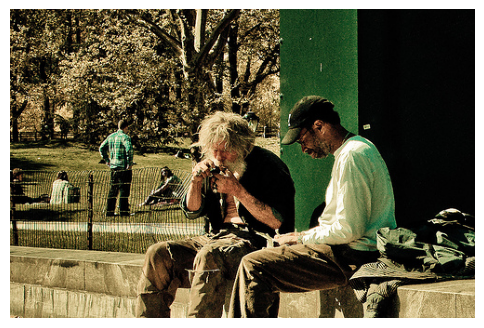

Image index: 654

Ground-truth captions:
- Two black and white homeless men smoking and sitting outside next to a building.
- A man sitting with an elderly homeless person in a park.
- Two men are sitting on concrete slabs in a park.
- Two homeless men sitting at a park.
- Two men smoking outside of a park.

Top retrieved captions:
1. The two passengers are seated in the waiting area a couple of chairs apart and yet both seem to be alone. | score=0.579 
2. A male with brown hair and glasses, sitting on a step in front of a home. | score=0.547 
3. There are five people in the picture, two guys talking near a sign for free advice, a man and women facing away and another man on a phone in the background. | score=0.541 
4. Two black and white homeless men smoking and sitting outside next to a building. | score=0.539 ✅
5. A man with dreadlocks is playing with the hair of a woman who is sitting on a chair on a cobblestone street. | score=0.536 
-----------------------------------------------

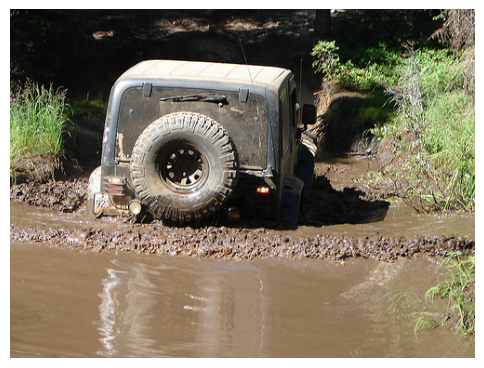

Image index: 114

Ground-truth captions:
- The car sinks up to the tops of its wheels in the mud.
- A four wheel drive car is driving through the mud.
- There is a jeep stuck in mud up to the doors.
- A blue Jeep drive into deep, muddy water.
- A Jeep gets wheel high in mud.

Top retrieved captions:
1. A yellow car driving through a lot of snow | score=0.570 
2. A four wheel drive car is driving through the mud. | score=0.543 
3. A little girl is walking in a puddle of rain water in a hole in the road. | score=0.515 
4. A man wading in a lake dips his long hair into the water and quickly throws his head back making a brief rainbow of water overhear. | score=0.498 
5. A firefighter sprays water onto a gigantic pile or burning ash that includes flames and dark smoke. | score=0.434 
----------------------------------------------------------------------------------------------------


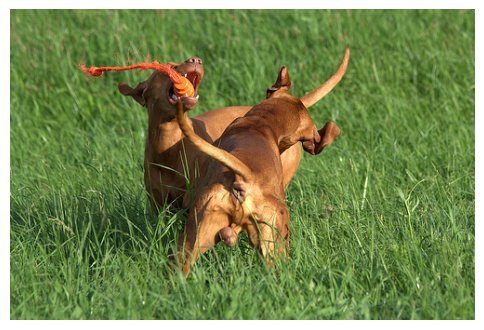

Image index: 25

Ground-truth captions:
- Two dogs are playing rough in a green field of grass.
- On grass, two brown dogs tussle for orange toy.
- Two dogs play with an orange toy in tall grass.
- Two large brown dogs are playing in the grass.
- Dogs fight in grass over toy.

Top retrieved captions:
1. Two grayish-brown dogs looking at something in the grass. | score=0.613 
2. The large brown dog is chasing after the little brown dog. | score=0.595 
3. A small brown dog is running over grass littered with dry leaves. | score=0.571 
4. A black poodle and another dog with something in its mouth are playing on some dry grass. | score=0.556 
5. Brown dog on grass, drinking water spray from left side of frame. | score=0.541 
----------------------------------------------------------------------------------------------------


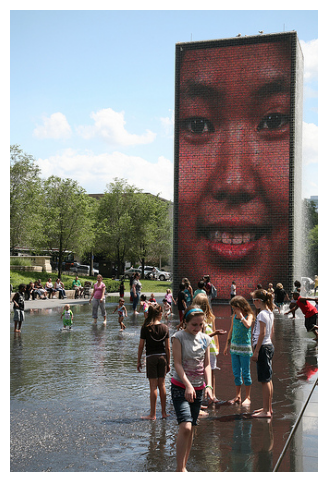

Image index: 759

Ground-truth captions:
- A group of people, mostly children, are playing in a shallow wading pool.
- Children play in a shallow pool next to a large image of a girl's face.
- A group of girls are playing in a water fountain in the sun.
- A large display of a child's face over a water park.
- A group of children are getting wet in a park.

Top retrieved captions:
1. The back of a woman with blue dreadlocks and a colored checkered backpack, sitting and facing a crowd of people. | score=0.531 
2. A crowd of people, some standing by a river, some in the river with old buildings in the background. | score=0.526 
3. A crowd of people are standing behind a railing watching something in the distance. | score=0.525 
4. Tourists stroll the streets between historic buildings. | score=0.524 
5. A group of people are standing outside at a carnival, near a ride called the Green Jungle. | score=0.511 
----------------------------------------------------------------------------------

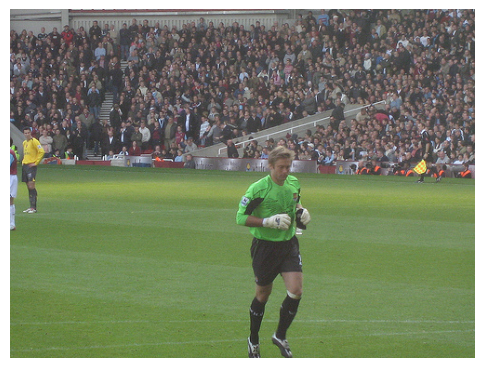

Image index: 281

Ground-truth captions:
- A soccer team player in a green shirt is running off the field.
- A soccer player wearing a green shirt is jogging on the field.
- A man in a green top and gloves trots across a ball field.
- A soccer player in a green uniform is running.
- A soccer player in green runs down the field.

Top retrieved captions:
1. A soccer team player in a green shirt is running off the field. | score=0.708 ✅
2. Four female teens are shown playing soccer on a grassy field on an overcast day, two of them in uniforms consisting of red-and-white vertically-striped jerseys and blue shorts. | score=0.693 
3. A woman in blue shorts and a red and white striped shirt throws a soccer ball out onto a green field with players on it. | score=0.691 
4. A football player preparing a football for a field goal kick, while his teammates can coach watch him. | score=0.634 
5. A boy wearing a white and green athletic uniform is about to kick a soccer ball. | score=0.624 
--------

In [66]:
from src.visualization.retrieval import show_image_to_text_retrieval_examples

show_image_to_text_retrieval_examples(
    hf_dataset=val_data,
    similarity_matrix=similarity_matrix,
    n_examples=5,
    top_k=5,
    random_state=RANDOM_SEED,
)

Observation

The qualitative retrieval examples demonstrate that Mini-CLIP successfully captures the general semantic content of images. Even when the exact ground-truth caption is not ranked first, the retrieved captions are often visually and semantically related, describing similar objects, actions, or environments.

The strongest retrieval performance is observed for images containing distinctive objects or activities, such as sports or animals. In contrast, crowded scenes and examples requiring fine-grained semantic understanding remain more challenging, with the model retrieving captions that capture the overall scene but miss important details. These observations are consistent with the findings from the previous error analysis, where semantically similar image-caption pairs were identified as the most difficult cases.

## All-Caption Retrieval Evaluation

The previous retrieval evaluation used only one caption per image as the correct target. However, each Flickr30k image has five valid captions, so a retrieved caption should be considered correct if it belongs to the same image.

This section evaluates Mini-CLIP using all five captions per validation image, which provides a fairer estimate of retrieval performance on Flickr30k.

In [ ]:
# create embeddings for all validation captions
from src.text.tokenization import encode_caption

all_caption_tensors = []
caption_image_indices = []
caption_texts = []

for image_idx, sample in enumerate(val_data):
    for caption in sample["caption"]:
        caption_ids = encode_caption(
            caption,
            vocab,
            max_length=MAX_CAPTION_LENGTH,
        )

        all_caption_tensors.append(
            torch.tensor(caption_ids, dtype=torch.long)
        )
        caption_image_indices.append(image_idx)
        caption_texts.append(caption)

all_caption_tensors = torch.stack(all_caption_tensors)

all_caption_tensors.shape, len(caption_image_indices), len(caption_texts)

(torch.Size([5070, 32]), 5070, 5070)

In [71]:
# Encode all captions
model.eval()

all_caption_embeddings = []

with torch.inference_mode():
    for start_idx in range(0, len(all_caption_tensors), BATCH_SIZE):
        batch = all_caption_tensors[start_idx:start_idx + BATCH_SIZE].to(DEVICE)

        dummy_image_embeddings = torch.zeros(
            batch.shape[0],
            IMAGE_FEATURE_DIM,
            device=DEVICE,
        )

        _, text_proj = model(dummy_image_embeddings, batch)

        all_caption_embeddings.append(text_proj.cpu())

all_caption_embeddings = torch.cat(all_caption_embeddings)

all_caption_embeddings.shape

torch.Size([5070, 256])

In [72]:
# Compute image-to-all-captions similarities
all_caption_similarity_matrix = all_image_embeddings @ all_caption_embeddings.T

all_caption_similarity_matrix.shape

torch.Size([1014, 5070])

In [73]:
from src.evaluation.retrieval import image_to_text_top_k_accuracy_multi_caption

all_caption_retrieval_metrics = pd.DataFrame(
    [
        {
            "direction": "Image-to-text (all captions)",
            "top_1": image_to_text_top_k_accuracy_multi_caption(
                all_caption_similarity_matrix,
                caption_image_indices,
                k=1,
            ),
            "top_5": image_to_text_top_k_accuracy_multi_caption(
                all_caption_similarity_matrix,
                caption_image_indices,
                k=5,
            ),
            "top_10": image_to_text_top_k_accuracy_multi_caption(
                all_caption_similarity_matrix,
                caption_image_indices,
                k=10,
            ),
        }
    ]
)

all_caption_retrieval_metrics

,direction,top_1,top_5,top_10
0,Image-to-text (all captions),0.196252,0.451677,0.559172


In [74]:
all_caption_retrieval_metrics.to_csv(
    RESULTS_DIR / "mini_clip_all_caption_retrieval_metrics.csv",
    index=False,
)

### Observation

Using all five valid captions per image improves the image-to-text retrieval metrics compared with the single-caption evaluation. This indicates that Mini-CLIP often retrieves a correct alternative caption rather than the specific caption selected for evaluation, making the all-caption protocol a fairer measure of retrieval performance on Flickr30k.

The results show that for more than half of the validation images, at least one correct caption is ranked within the top 10 retrieved captions, despite searching among more than 5,000 candidate captions. This demonstrates that the model has learned a meaningful shared embedding space capable of retrieving semantically relevant image-caption pairs.

### Qualitative Multi-Caption Retrieval

In the all-caption retrieval setup, each image is compared against all validation captions. A retrieval is considered correct if any of the five ground-truth captions for the image appears among the top results.

This qualitative check helps show whether Mini-CLIP retrieves alternative valid captions for the image, not only the single caption used in the stricter retrieval setup.

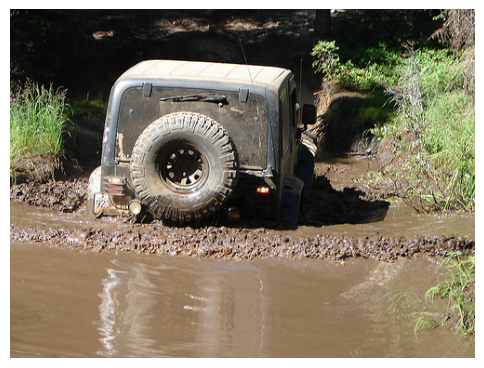

Image index: 114

Ground-truth captions:
1. The car sinks up to the tops of its wheels in the mud.
2. A four wheel drive car is driving through the mud.
3. There is a jeep stuck in mud up to the doors.
4. A blue Jeep drive into deep, muddy water.
5. A Jeep gets wheel high in mud.

Top retrieved captions:
1. A monster truck gets stuck in a muddy hole. | score=0.628 
2. A yellow car driving through a lot of snow | score=0.570 
3. A Jeep gets wheel high in mud. | score=0.566 ✅ Ground truth #5
4. A person kneeling in front of a vehicle | score=0.543 
5. A four wheel drive car is driving through the mud. | score=0.543 ✅ Ground truth #2
6. A four wheel drive car is driving through the mud. | score=0.543 ✅ Ground truth #2
7. A blue Jeep drive into deep, muddy water. | score=0.538 ✅ Ground truth #4
8. A little girl is walking in a puddle of rain water in a hole in the road. | score=0.515 
9. A brown dog is bending down trying to drink from a jet of water. | score=0.515 
10. A very wet brown do

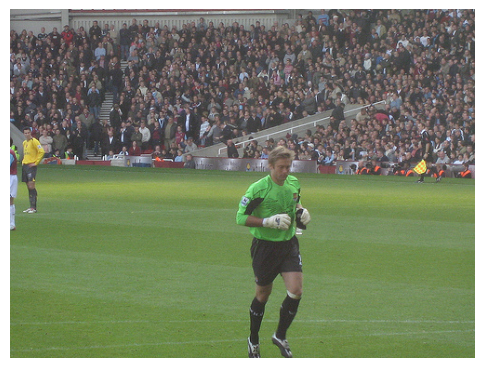

Image index: 281

Ground-truth captions:
1. A soccer team player in a green shirt is running off the field.
2. A soccer player wearing a green shirt is jogging on the field.
3. A man in a green top and gloves trots across a ball field.
4. A soccer player in a green uniform is running.
5. A soccer player in green runs down the field.

Top retrieved captions:
1. A soccer player wearing a green shirt is jogging on the field. | score=0.712 ✅ Ground truth #2
2. A soccer team player in a green shirt is running off the field. | score=0.708 ✅ Ground truth #1
3. A female rugby player runs with a rugby ball during a match. | score=0.693 
4. Four female teens are shown playing soccer on a grassy field on an overcast day, two of them in uniforms consisting of red-and-white vertically-striped jerseys and blue shorts. | score=0.693 
5. A woman in blue shorts and a red and white striped shirt throws a soccer ball out onto a green field with players on it. | score=0.691 
6. A female soccer player is t

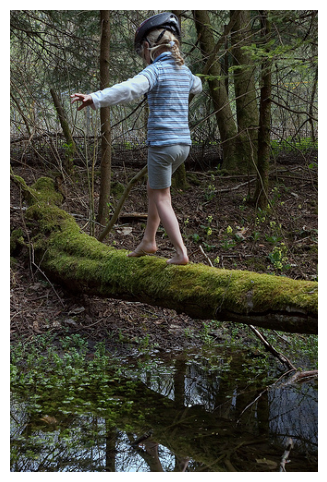

Image index: 444

Ground-truth captions:
1. A young girl in a helmet walks barefoot across a mossy tree trunk that is lying over water.
2. A young barefoot girl wearing a helmet walks down a mossy covered fallen down tree.
3. A girl wearing a bike helmet is walking across a mossy tree branch over water.
4. A young girl in blue and a bicycle helmet is walking across a log in a pond.
5. A child walking on a fallen tree.

Top retrieved captions:
1. A young barefoot girl wearing a helmet walks down a mossy covered fallen down tree. | score=0.723 ✅ Ground truth #2
2. Woman hangs on tree limb. | score=0.652 
3. A girl posing on a cliff over a river. | score=0.650 
4. A child walking on a fallen tree. | score=0.648 ✅ Ground truth #5
5. A woman is standing on a rock overlooking a river. | score=0.641 
6. A person is standing next to a wooden fence with flowering trees nearby. | score=0.638 
7. A young girl in a helmet walks barefoot across a mossy tree trunk that is lying over water. | score=0

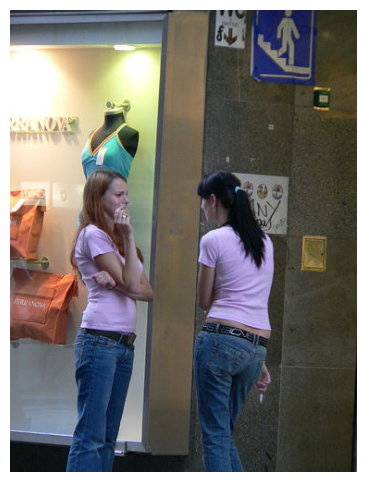

Image index: 555

Ground-truth captions:
1. Two women wearing pink T-shirts and blue jeans converse outside clothing store.
2. Two women are standing outside a store wearing pink shirts and jeans.
3. One woman is smoking and talking to another woman.
4. Two women talk in front of a clothing store.
5. Two female co-workers talk on break.

Top retrieved captions:
1. There is a young woman with a bag smiling in front of a building. | score=0.555 
2. A man standing in the door of a laundry mat. | score=0.552 
3. An older woman and a young girl face each other over a kitchen counter. | score=0.536 
4. Two adult woman stand in front of a class of young students. | score=0.524 
5. A little boy in a gray shirt stands between two seated women. | score=0.524 
6. A woman talks to a young girl over a counter. | score=0.524 
7. A woman in a green shirt and face paint is looking at something. | score=0.515 
8. Adults in the kitchen of someone's house eating and looking at something in front of them.

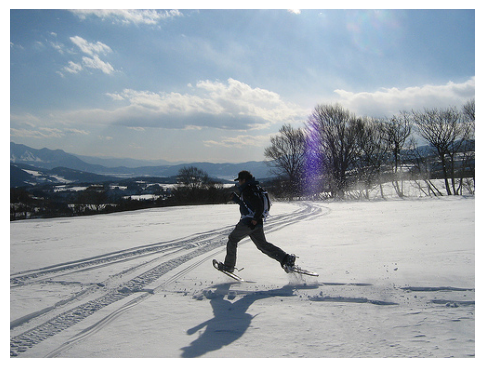

Image index: 888

Ground-truth captions:
1. A person with an apparatus attached to his shoes is running through a flat, snowy area with trees and mountains in the distance.
2. An individual in snow gear running through a snowy field on snowshoes on a bright, winter's day.
3. A man is running in snowshoes across a snow covered field, with mountains in the background.
4. Someone in snowshoes is vaulting across an open area outside.
5. A man runs through the snow with the aid of snowshoes.

Top retrieved captions:
1. Skiiers are walking through the snow near the mountains. | score=0.732 
2. Two poodles are running through the snow. | score=0.716 
3. Woman wearing black snow pants and jacket, walking down a snowy hill. | score=0.714 
4. A bicyclist rides down the road near snow. | score=0.689 
5. A person with an apparatus attached to his shoes is running through a flat, snowy area with trees and mountains in the distance. | score=0.680 ✅ Ground truth #1
6. A main shoveling snow, off the s

In [80]:
show_image_to_text_retrieval_examples(
    hf_dataset=val_data,
    similarity_matrix=all_caption_similarity_matrix,
    n_examples=3,
    top_k=10,
    random_state=RANDOM_SEED,
    multi_caption=True,
    candidate_captions=caption_texts,
    sample_indices=[114, 281, 444, 555, 888], # couple from previous and few new examples
)

Observation

The multi-caption retrieval examples show that Mini-CLIP often retrieves several valid captions for the same image when multiple ground-truth captions are considered. In successful examples, the model ranks different correct descriptions of the same image within the top results, demonstrating that the learned embedding space captures semantic similarity rather than memorizing a single caption.

Even in failure cases, the retrieved captions are often visually plausible. For example, the model may retrieve captions that describe similar people, actions, environments, or visual layouts, even when none of the exact ground-truth captions appear in the top results. This suggests that Mini-CLIP has learned meaningful image-text associations, but still struggles with fine-grained details such as specific objects, actions, attributes, or relationships.

## Qualitative Text-to-Image Retrieval

In this experiment, a caption is used as a query, and Mini-CLIP retrieves the most similar images from the validation set. This evaluates the opposite retrieval direction: instead of finding captions for an image, the model searches for images that best match a text description.

Query caption:
Two black and white homeless men smoking and sitting outside next to a building.


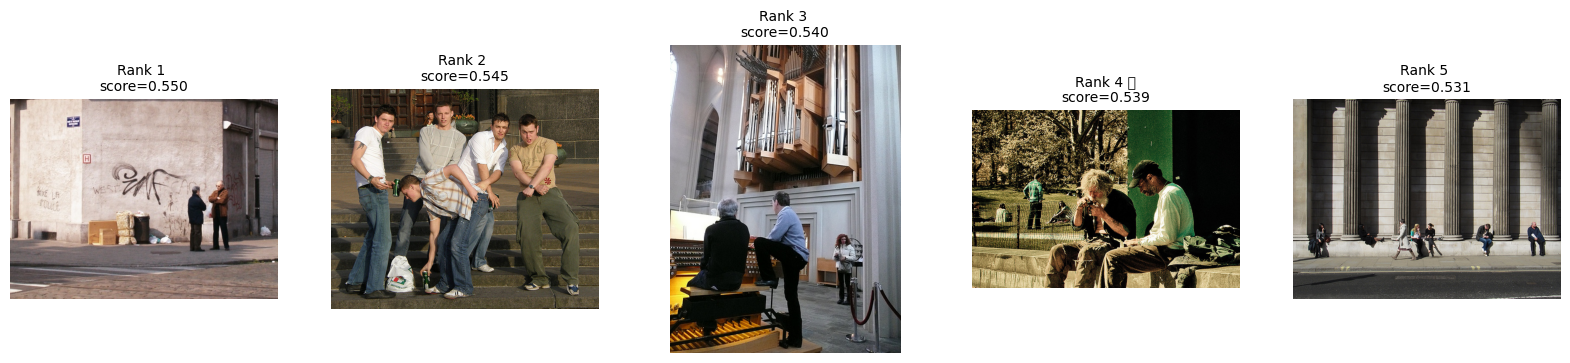

----------------------------------------------------------------------------------------------------
Query caption:
The car sinks up to the tops of its wheels in the mud.


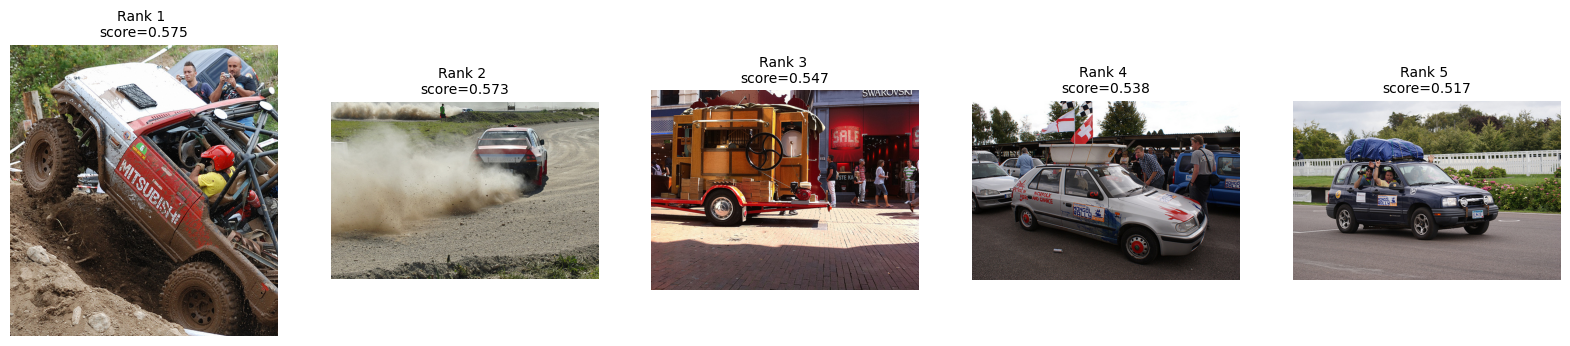

----------------------------------------------------------------------------------------------------
Query caption:
Two dogs are playing rough in a green field of grass.


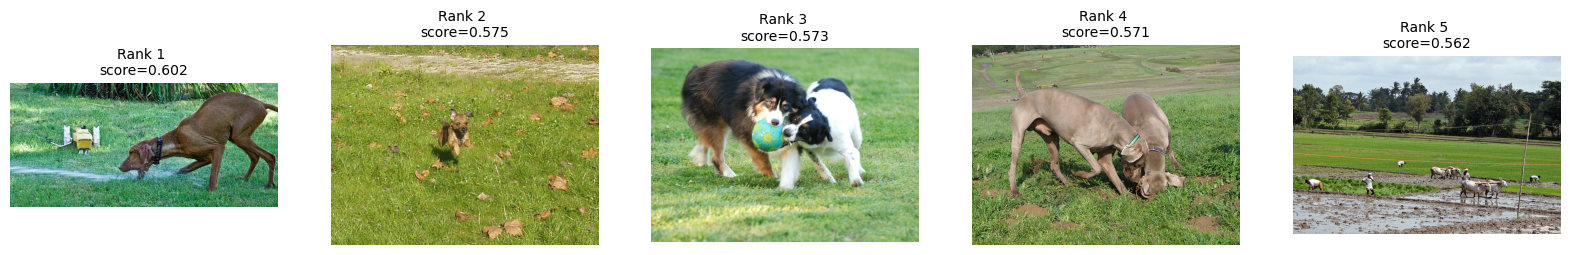

----------------------------------------------------------------------------------------------------
Query caption:
A group of people, mostly children, are playing in a shallow wading pool.


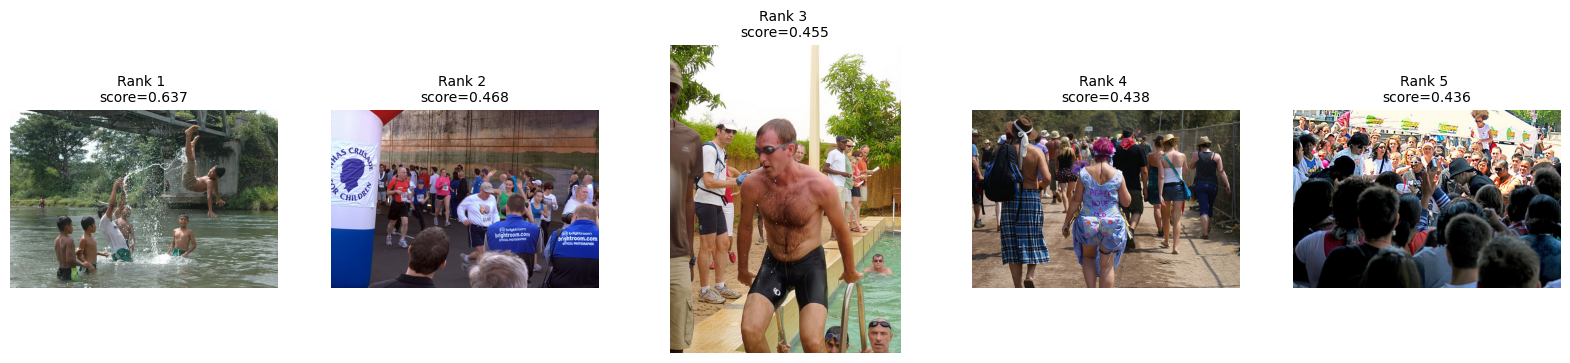

----------------------------------------------------------------------------------------------------
Query caption:
A soccer team player in a green shirt is running off the field.


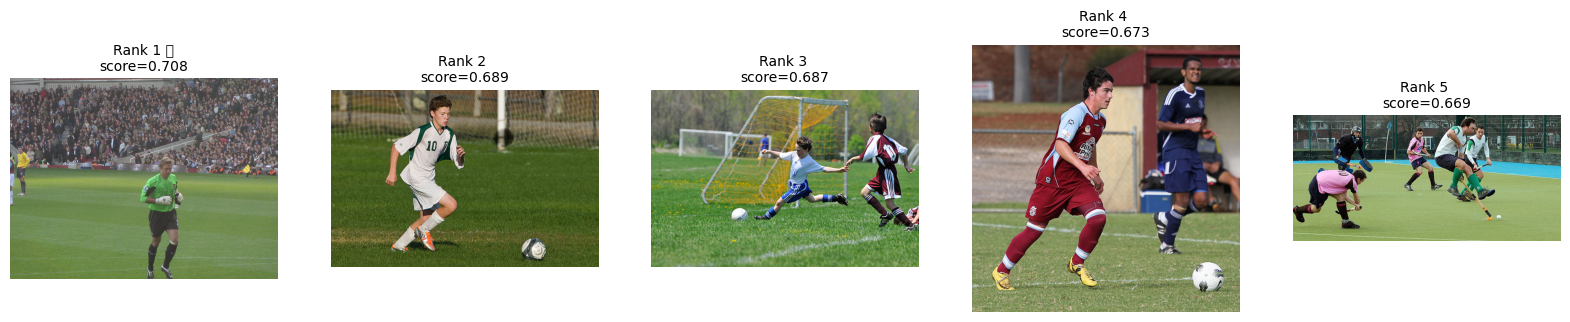

----------------------------------------------------------------------------------------------------


In [84]:
from src.visualization.retrieval import show_text_to_image_retrieval_examples

show_text_to_image_retrieval_examples(
    hf_dataset=val_data,
    similarity_matrix=similarity_matrix.T,
    n_examples=5,
    top_k=5,
    random_state=RANDOM_SEED,
)

Observation

The text-to-image retrieval examples show that Mini-CLIP retrieves highly relevant images for captions describing distinctive objects or clear actions, such as vehicles in mud, dogs on grass, or sports scenes. In these cases, the top retrieved images are often visually and semantically close to the query caption.

The model struggles more with complex scenes involving groups of people or multiple simultaneous activities. Although the correct image may still appear among the top results, the retrieved set often includes visually diverse images that share only broad concepts, such as people outdoors or crowded environments. This suggests that Mini-CLIP captures strong general semantic similarity but still has difficulty with fine-grained scene details and complex human interactions.